# Практика: DBSCAN — плотностная кластеризация

## Что вы сделаете
В этом ноутбуке вы:

1. исследуете нелинейные 2D-датасеты и убедитесь в ограничениях K-Means;
2. построите **k-distance plot** и выберете оптимальный параметр `eps`;
3. применените **DBSCAN** и проанализируете результаты;
4. сравните DBSCAN с K-Means на нелинейных данных;
5. исследуете влияние гиперпараметров `eps` и `min_samples`;
6. применените DBSCAN к реальному датасету **Wine** и проанализируете шумовые точки;
7. сравните силуэт DBSCAN и K-Means, сделаете выводы.

## Важно
- Заполняйте все ячейки с пометкой `# YOUR CODE HERE`.
- Не удаляйте проверки: они подскажут, правильно ли вы идёте.
- Вопросы для размышления помогут вам глубже понять алгоритм.

## Датасеты
- **`make_moons`** и **`make_circles`** из `sklearn.datasets`: 2D-данные с нелинейными кластерами.
- **Wine** (`load_wine`): реальный многомерный датасет (13 признаков, 3 класса).

## Что сдавать
1. Заполненный ноутбук со всеми графиками.
2. Краткие выводы в конце каждого раздела.
3. Итоговый вывод: когда DBSCAN лучше K-Means и когда нет.

## Краткая теория

### Типы точек в DBSCAN

DBSCAN задаётся двумя параметрами: радиусом окрестности `eps` (ε) и минимальным числом точек `min_samples`.

- **Корневая точка** (core): в её ε-окрестности ≥ `min_samples` точек.
- **Граничная точка** (border): в её ε-окрестности < `min_samples`, но она достижима из корневой.
- **Шумовая точка** (noise): не является ни корневой, ни граничной → метка **-1**.

### Как работает алгоритм

1. Для каждой непосещённой точки найти её ε-окрестность.
2. Если точек ≥ `min_samples` — начать новый кластер.
3. Рекурсивно расширить кластер через цепочки плотно достижимых точек.
4. Оставшиеся точки → шум (метка -1).

### Как выбрать eps: k-distance plot

Для каждой точки вычисляют расстояние до её k-го ближайшего соседа (k = `min_samples`). Отсортированный по убыванию график этих расстояний называется **k-distance plot**. Резкий перегиб («локоть») указывает на оптимальное значение `eps`.

---
## Шаг 1. Импорты и настройки

In [85]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.cluster import DBSCAN, KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.datasets import make_moons, make_circles, load_wine
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Для воспроизводимости
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Импорты выполнены успешно!")

Импорты выполнены успешно!


---
## Шаг 2. Исследование нелинейных датасетов

Сгенерируем два датасета, с которыми K-Means заведомо не справится.

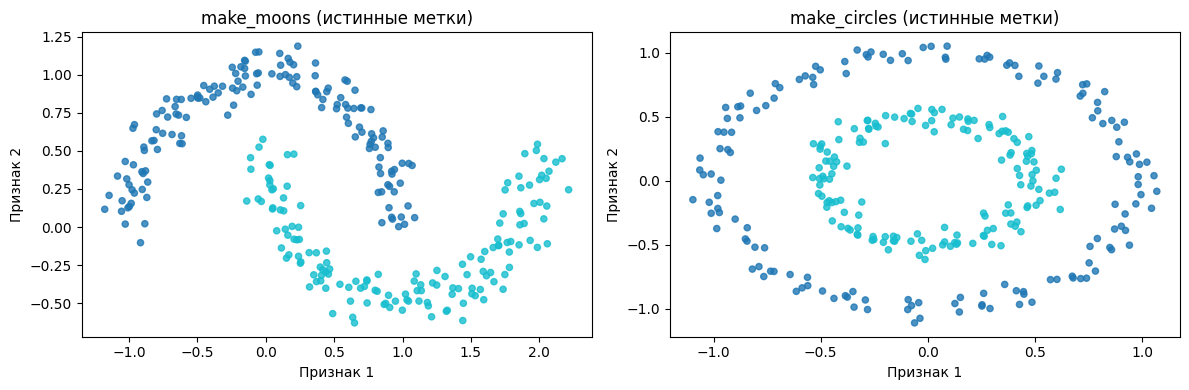

In [86]:
# Генерация датасетов
X_moons, y_moons = make_moons(n_samples=300, noise=0.08, random_state=RANDOM_STATE)
X_circles, y_circles = make_circles(n_samples=300, noise=0.05,
                                     factor=0.5, random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(X_moons[:, 0], X_moons[:, 1],
                c=y_moons, cmap='tab10', s=20, alpha=0.8)
axes[0].set_title("make_moons (истинные метки)")
axes[0].set_xlabel("Признак 1")
axes[0].set_ylabel("Признак 2")

axes[1].scatter(X_circles[:, 0], X_circles[:, 1],
                c=y_circles, cmap='tab10', s=20, alpha=0.8)
axes[1].set_title("make_circles (истинные метки)")
axes[1].set_xlabel("Признак 1")
axes[1].set_ylabel("Признак 2")

plt.tight_layout()
plt.show()

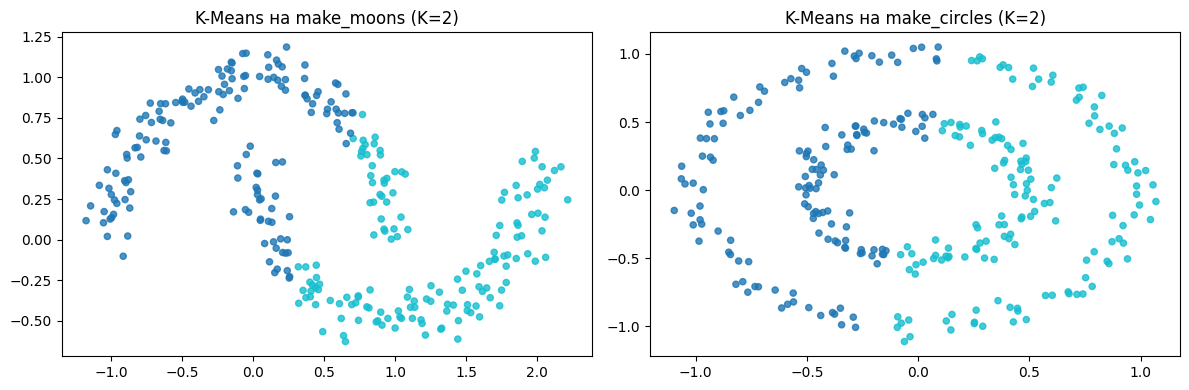

In [87]:
# Применим K-Means к этим датасетам
# YOUR CODE HERE
# 1. Создайте KMeans с n_clusters=2, random_state=RANDOM_STATE
# 2. Обучите на X_moons и X_circles
# 3. Получите метки кластеров

kmeans_moons = KMeans(n_clusters=2, random_state=RANDOM_STATE)  # замените None
kmeans_moons.fit(X_moons)
labels_km_moons = kmeans_moons.labels_

kmeans_circles = KMeans(n_clusters=2, random_state=RANDOM_STATE)
kmeans_circles.fit(X_circles)
labels_km_circles = kmeans_circles.labels_

# Визуализация результатов K-Means
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(X_moons[:, 0], X_moons[:, 1],
                c=labels_km_moons, cmap='tab10', s=20, alpha=0.8)
axes[0].set_title("K-Means на make_moons (K=2)")

axes[1].scatter(X_circles[:, 0], X_circles[:, 1],
                c=labels_km_circles, cmap='tab10', s=20, alpha=0.8)
axes[1].set_title("K-Means на make_circles (K=2)")

plt.tight_layout()
plt.show()

**❓ Вопрос для размышления:** Почему K-Means не может правильно разделить «луны» и «кольца»? Связано ли это с формой функционала ошибки?

Это действительно связано с функционалом ошибки и с логикой работы kmeans. Штраф точки тем больше, чем больше расстояние ее от центроида (более того, алгоритм штрафует не просто за расстояние, а за квадрат расстояния).

---
## Шаг 3. k-Distance Plot и выбор eps

Построим k-distance plot для датасета `make_moons`. Используем k = 5 (= `min_samples`).

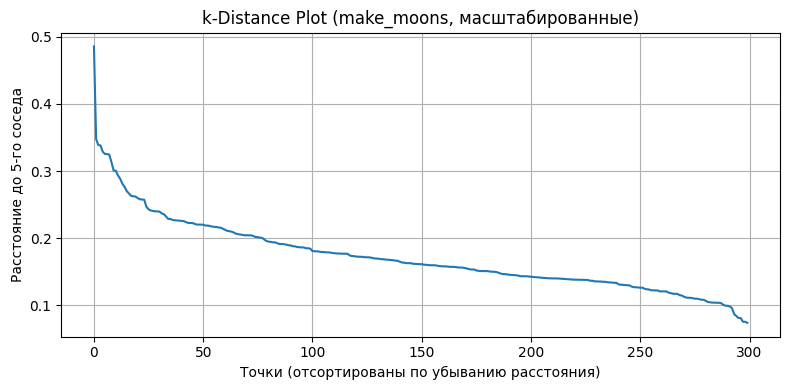

Найдите 'локоть' на графике и запишите подходящее значение eps:
0.25


In [88]:
# Масштабируем данные
scaler_moons = StandardScaler()
X_moons_scaled = scaler_moons.fit_transform(X_moons)

k = 5

# YOUR CODE HERE
# 1. Создайте NearestNeighbors(n_neighbors=k) и обучите на X_moons_scaled
# 2. Вызовите .kneighbors() для получения матрицы расстояний
# 3. Возьмите расстояние до k-го соседа (последний столбец distances)
# 4. Отсортируйте по убыванию
nn = NearestNeighbors(n_neighbors=k)
nn.fit(X_moons_scaled)
distance_matrix = nn.kneighbors()
k_neighbor = distance_matrix[0][:, k-1]

k_distances_moons = np.sort(k_neighbor)[::-1]  # замените

plt.figure(figsize=(8, 4))
plt.plot(k_distances_moons)
plt.xlabel("Точки (отсортированы по убыванию расстояния)")
plt.ylabel(f"Расстояние до {k}-го соседа")
plt.title("k-Distance Plot (make_moons, масштабированные)")
plt.grid(True)
plt.tight_layout()
plt.show()

print("Найдите 'локоть' на графике и запишите подходящее значение eps:")
print("0.25")

**❓ Вопрос для размышления:** Где находится «локоть»? Как он указывает на границу между точками кластеров и шумом?

Он находится в точке перелома, где график становится более пологим. В данном случае это примерно на значении 0.25. Именно это место является границей между точками кластеров и шумом, потому что слева от этой точки расстояния до k-того соседа резко возрастают. Это значит, что точка расположена дальше от областей кучности, чем остальные, а значит это более шумные точки, чем остальные. И когда мы берем эпсилон на перегибе, все точки слева от значения эпсилон обретают метку -1 и становятся шумом.

---
## Шаг 4. DBSCAN на нелинейных датасетах

Применим DBSCAN к `make_moons` и `make_circles`. Обратите внимание на масштабирование.

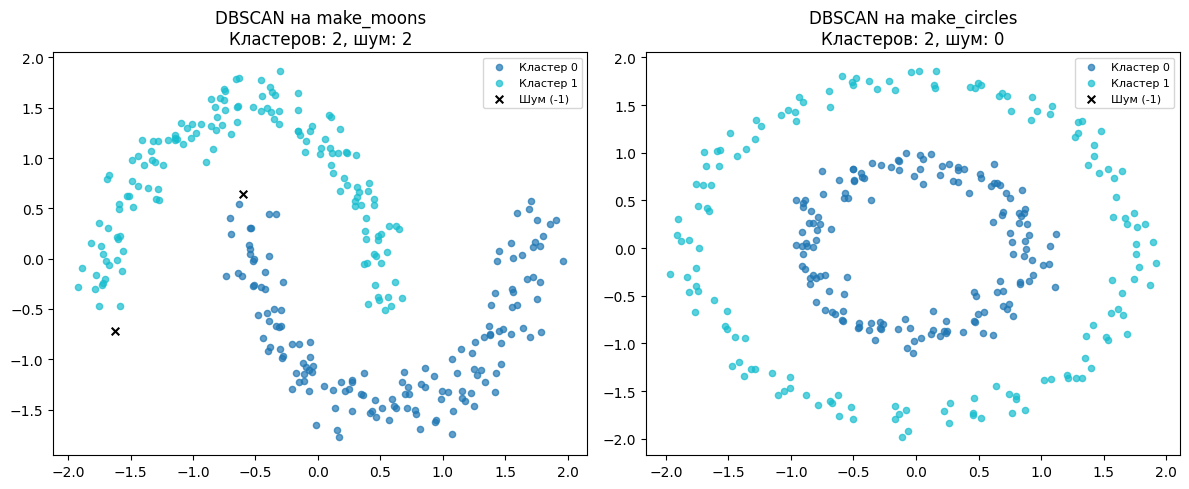

In [89]:
# Масштабируем make_circles
scaler_circles = StandardScaler()
X_circles_scaled = scaler_circles.fit_transform(X_circles)

# YOUR CODE HERE
# 1. Создайте DBSCAN с подобранным eps (из k-distance plot) и min_samples=5
# 2. Примените fit_predict к X_moons_scaled и X_circles_scaled
# 3. Подберите параметры так, чтобы алгоритм нашёл 2 кластера

db_moons = DBSCAN(eps=0.25, min_samples=5)   # замените

# --------------------------------------------------------------------------------
# можно поставить eps = 0.3, тогда не будет шумовых точек, что будет видно дальше
# --------------------------------------------------------------------------------

db_moons.fit(X_moons_scaled)
labels_db_moons = db_moons.labels_

db_circles = DBSCAN(eps=0.4, min_samples=3)
db_circles.fit(X_circles_scaled)
labels_db_circles = db_circles.labels_

# Вспомогательная функция для визуализации
def plot_dbscan_results(X, labels, title, ax):
    """Визуализирует результаты DBSCAN.
    Корневые точки — крупные, граничные — обычные, шум — крестики."""
    noise_mask = labels == -1
    colors = cm.tab10(np.linspace(0, 1, max(labels)+1)) if max(labels) >= 0 else []
    
    for i in range(max(labels)+1):
        mask = labels == i
        ax.scatter(X[mask, 0], X[mask, 1], s=20, alpha=0.7,
                   color=colors[i], label=f'Кластер {i}')
    
    ax.scatter(X[noise_mask, 0], X[noise_mask, 1],
               s=30, c='black', marker='x', label='Шум (-1)')
    
    n_cl = max(labels) + 1 if max(labels) >= 0 else 0
    n_noise = noise_mask.sum()
    ax.set_title(f"{title}\nКластеров: {n_cl}, шум: {n_noise}")
    ax.legend(fontsize=8)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_dbscan_results(X_moons_scaled, labels_db_moons, "DBSCAN на make_moons", axes[0])
plot_dbscan_results(X_circles_scaled, labels_db_circles, "DBSCAN на make_circles", axes[1])
plt.tight_layout()
plt.show()

---
## Шаг 5. Сравнение DBSCAN и K-Means на нелинейных данных

In [90]:
# Сравнение силуэта DBSCAN vs K-Means для make_moons

# YOUR CODE HERE
# 1. Обучите KMeans(n_clusters=2) на X_moons_scaled
# 2. Вычислите silhouette_score для K-Means
# 3. Вычислите silhouette_score для DBSCAN (только для некластерных точек!)
#    Подсказка: исключите точки с labels == -1

kmeans_moons = KMeans(n_clusters=2)
kmeans_moons.fit(X_moons_scaled)
labels_km_moons = kmeans_moons.labels_

score_kmeans = silhouette_score(X_moons_scaled, labels_km_moons)  # замените
score_dbscan = silhouette_score(X_moons_scaled[labels_db_moons != -1], labels_db_moons[labels_db_moons != -1])

print("=== Коэффициент силуэта на make_moons ===")
print(f"K-Means (K=2): {score_kmeans:.3f}" if score_kmeans is not None else "K-Means: не вычислен")
print(f"DBSCAN:        {score_dbscan:.3f}" if score_dbscan is not None else "DBSCAN: не вычислен")

=== Коэффициент силуэта на make_moons ===
K-Means (K=2): 0.494
DBSCAN:        0.387


**❓ Вопрос для размышления:** Какой алгоритм получил лучший силуэт? Соответствует ли это визуальному впечатлению? Можно ли всегда доверять силуэту как абсолютной мере качества?

K-Means получил лучший силуэт, но это не отражает реальности и не соответствует визуальному впечатлению, так как силуэт "одобряет" плотные, собранные в кучу, похожие на сферу кластеры. Поэтому для DBSCAN'а считать силуэт глупость.

---
## Шаг 6. Исследование влияния гиперпараметров

Посмотрим, как меняется результат DBSCAN при разных значениях `eps` и `min_samples`.

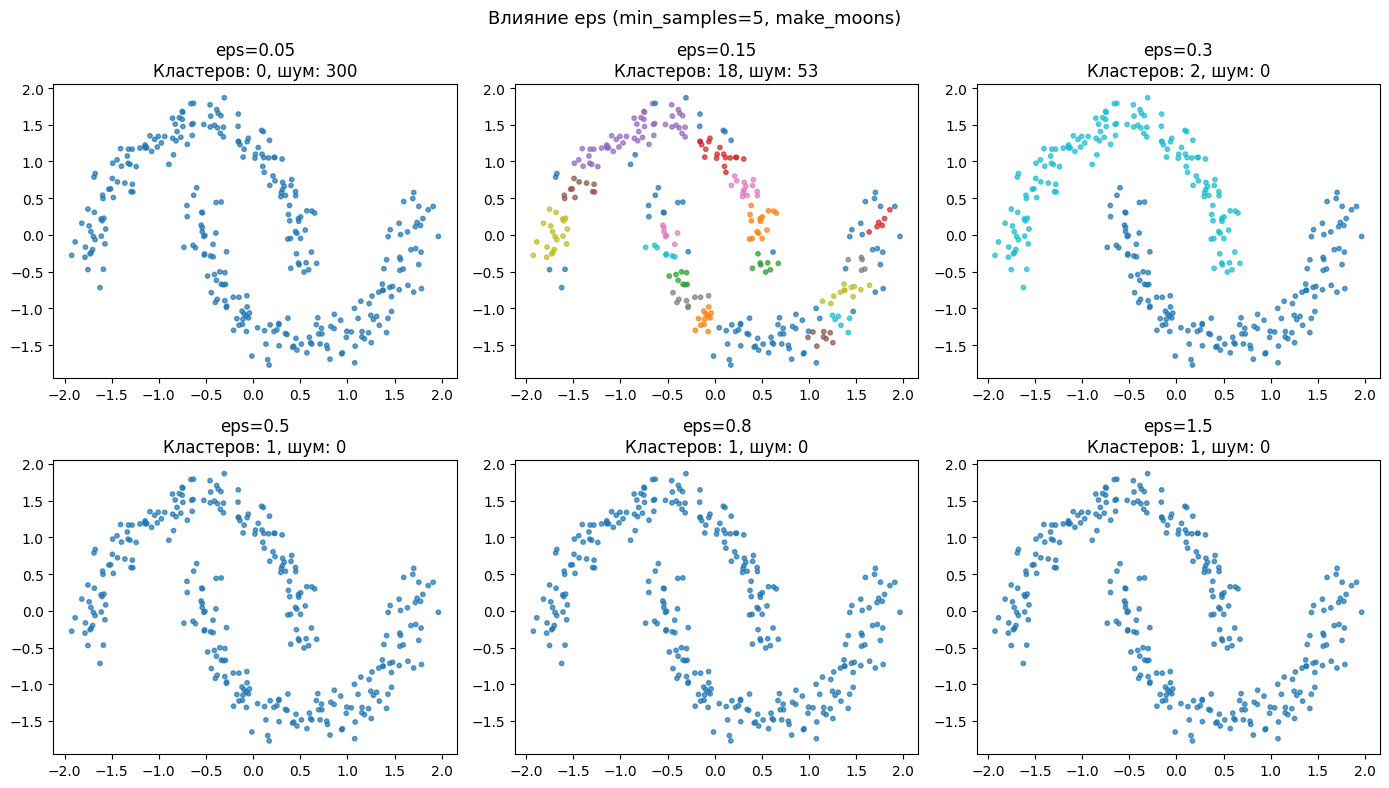

In [91]:
# Сетка eps при фиксированном min_samples=5
eps_values = [0.05, 0.15, 0.3, 0.5, 0.8, 1.5]
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, eps_val in enumerate(eps_values):
    # YOUR CODE HERE
    # 1. Запустите DBSCAN(eps=eps_val, min_samples=5) на X_moons_scaled
    # 2. Получите метки
    # 3. Посчитайте число кластеров и шумовых точек
    # 4. Отобразите scatter plot с цветами по меткам
    #    Шумовые точки (label == -1) рисуйте чёрными крестиками
    db_moons_i = DBSCAN(eps=eps_val, min_samples=5)
    db_moons_i.fit(X_moons_scaled)
    labels_i = db_moons_i.labels_  # замените
    
    if labels_i is not None:
        n_cl = len(set(labels_i)) - (1 if -1 in labels_i else 0)
        n_noise = (labels_i == -1).sum()
        axes[i].scatter(X_moons_scaled[:, 0], X_moons_scaled[:, 1],
                        c=labels_i, cmap='tab10', s=10, alpha=0.7)
        axes[i].set_title(f"eps={eps_val}\nКластеров: {n_cl}, шум: {n_noise}")
    else:
        axes[i].set_title(f"eps={eps_val} (не вычислено)")

plt.suptitle("Влияние eps (min_samples=5, make_moons)", fontsize=13)
plt.tight_layout()
plt.show()

**❓ Вопрос для размышления:** При каком `eps` алгоритм нашёл два правильных кластера? Что происходит при слишком малом и слишком большом значении?

При eps = 0.3 алгоритм нашел 2 правильных кластера. При слишком малом значении eps в окрестность не попадает достаточное количество точек и либо образуется слишком много маленьких кластеров, либо, если eps слишком малый, почти каждая точка становится отдельным кластером. При слишком большом значении eps несколько кластеров сливаются в один, так как точка из соседнего кластера попадает в кластер из-за большого eps и кластеры сливаются.

---
## Шаг 7. DBSCAN на реальном датасете Wine

Теперь перейдём к реальным данным. Датасет Wine: 178 образцов вина из трёх сортов винограда, 13 химических признаков.

In [92]:
# Загрузка датасета Wine
wine = load_wine()
X_wine = wine.data
y_wine = wine.target  # истинные метки (не используем при кластеризации!)
feature_names = wine.feature_names

print(f"Форма данных: {X_wine.shape}")
print(f"Признаки: {feature_names}")
print(f"\nСтатистика признаков:")
df_wine = pd.DataFrame(X_wine, columns=feature_names)
print(df_wine.describe().round(2))

Форма данных: (178, 13)
Признаки: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Статистика признаков:
       alcohol  malic_acid     ash  alcalinity_of_ash  magnesium  \
count   178.00      178.00  178.00             178.00     178.00   
mean     13.00        2.34    2.37              19.49      99.74   
std       0.81        1.12    0.27               3.34      14.28   
min      11.03        0.74    1.36              10.60      70.00   
25%      12.36        1.60    2.21              17.20      88.00   
50%      13.05        1.87    2.36              19.50      98.00   
75%      13.68        3.08    2.56              21.50     107.00   
max      14.83        5.80    3.23              30.00     162.00   

       total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
count         178.00      178.00             

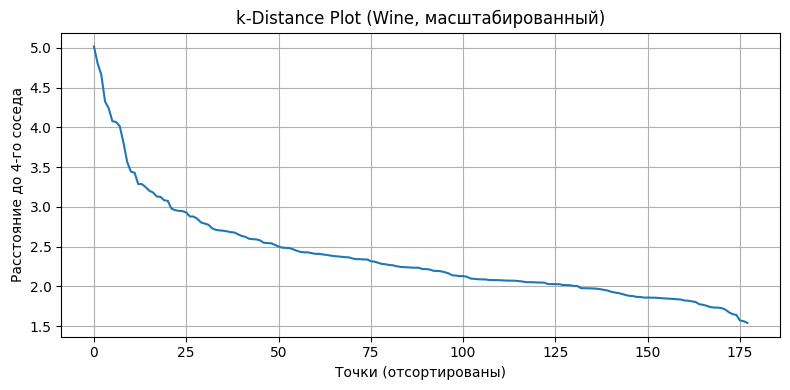

In [93]:
# YOUR CODE HERE
# 1. Масштабируйте X_wine с помощью StandardScaler
# 2. Постройте k-distance plot (k=4)
# 3. Визуально определите «локоть» и запишите подходящее eps

wine_scaler = StandardScaler()
X_wine_scaled = wine_scaler.fit_transform(X_wine)  # замените
k_wine = 4
wine_nn = NearestNeighbors(n_neighbors=k_wine)
wine_nn.fit(X_wine_scaled)
wine_distance_matrix = wine_nn.kneighbors()
k_dist_wine = np.sort(wine_distance_matrix[0][:, k_wine-1])[::-1]

plt.figure(figsize=(8, 4))
if k_dist_wine is not None:
    plt.plot(k_dist_wine)
plt.xlabel("Точки (отсортированы)")
plt.ylabel(f"Расстояние до {k_wine}-го соседа")
plt.title("k-Distance Plot (Wine, масштабированный)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [94]:
# YOUR CODE HERE
# 1. Запустите DBSCAN на X_wine_scaled с выбранным eps и min_samples=4
# 2. Выведите: число кластеров, число шумовых точек, долю шума
# 3. Если кластеров > 1, вычислите силуэт (исключив шум)

eps_wine = 2.1   # ИЗМЕНИТЕ на основе k-distance plot
#-------------------------------------------------------------------------------------------
# Изначально я поставил значение eps_wine=3.0, но тогда получался 1 класс. А для 
# дальнейшего сравнения пригодится разделить на несколько классов. Но, повторюсь, изначально 
# я увидел локоть в точке 3.0.
#-------------------------------------------------------------------------------------------

db_wine = DBSCAN(eps=eps_wine, min_samples=4)
db_wine.fit(X_wine_scaled)
labels_wine = db_wine.labels_  # замените

print("=== Результаты DBSCAN на Wine ===")
# ваш код для вывода статистики
cn = len(np.unique(labels_wine[labels_wine != -1]))
print("Число кластеров: ", cn)

for i in range(cn):
    print("Кол-во точек класса ", i, ": ", len(labels_wine[labels_wine == i]))
print("Кол-во шумовых точек: ", len(labels_wine[labels_wine == -1]))

print("Доля шума: ", round(len(labels_wine[labels_wine == -1])/len(labels_wine), 4))

if(cn > 1):
    clear_labels_wine = labels_wine[labels_wine != -1]
    score_db_wine = silhouette_score(X_wine_scaled[labels_wine != -1], clear_labels_wine)
    print(f"Силуэт: {score_db_wine:.3f}" if score_db_wine is not None else "Силуэт не вычислен, кластеров меньше 2")

=== Результаты DBSCAN на Wine ===
Число кластеров:  3
Кол-во точек класса  0 :  84
Кол-во точек класса  1 :  13
Кол-во точек класса  2 :  24
Кол-во шумовых точек:  57
Доля шума:  0.3202
Силуэт: 0.211


---
## Шаг 8. Анализ шумовых точек

Шумовые точки — это объекты, которые DBSCAN не смог отнести ни к одному кластеру. В задаче кластеризации они могут нести важную информацию.

In [95]:
# YOUR CODE HERE
# 1. Выберите строки X_wine, соответствующие шумовым точкам (labels_wine == -1)
# 2. Создайте DataFrame с признаками шумовых точек
# 3. Сравните среднее значение признаков шумовых точек
#    со средним по всей выборке (df_wine.mean())
# 4. Какие признаки у шумовых точек сильно отличаются от среднего?

noise_mask_wine = labels_wine == -1   # маска для шумовых точек
X_wine_noise = X_wine[noise_mask_wine]      # признаки шумовых точек

print("=== Средние значения признаков ===")
print(X_wine.shape)
print(df_wine.mean(axis=0))
print(X_wine_noise.mean(axis=0))
# ваш код

=== Средние значения признаков ===
(178, 13)
alcohol                          13.000618
malic_acid                        2.336348
ash                               2.366517
alcalinity_of_ash                19.494944
magnesium                        99.741573
total_phenols                     2.295112
flavanoids                        2.029270
nonflavanoid_phenols              0.361854
proanthocyanins                   1.590899
color_intensity                   5.058090
hue                               0.957449
od280/od315_of_diluted_wines      2.611685
proline                         746.893258
dtype: float64
[1.27394737e+01 2.54561404e+00 2.35315789e+00 2.00894737e+01
 1.01105263e+02 2.34070175e+00 2.01771930e+00 3.72456140e-01
 1.71385965e+00 4.44754386e+00 9.74315789e-01 2.54000000e+00
 6.45350877e+02]


In [96]:
df_wine_mean = pd.DataFrame([X_wine.mean(axis=0), X_wine_noise.mean(axis=0)], columns=df_wine.columns).T
df_wine_mean.columns = ["Среднее по всем", "Среднее по шумовым"]
df_wine_mean

,Среднее по всем,Среднее по шумовым
alcohol,13.000618,12.739474
malic_acid,2.336348,2.545614
ash,2.366517,2.353158
alcalinity_of_ash,19.494944,20.089474
magnesium,99.741573,101.105263
total_phenols,2.295112,2.340702
flavanoids,2.029270,2.017719
nonflavanoid_phenols,0.361854,0.372456
proanthocyanins,1.590899,1.713860
color_intensity,5.058090,4.447544


У шумовых точек больше всего отличается среднее значение признаков magnesium, proanthocyanins и proline.

**❓ Вопрос для размышления:** Чем отличаются шумовые точки от остальных? Являются ли они «плохими» данными или это реальные аномалии?

Чем отличаются я ответил выше. Являются ли они плохими или реальными аномалиями я затрудняюсь ответить, так как считаю, что некорректно сравнивать по средним значениям признака, так как шумовые точки могут быть симметрично расположены относительно среднего значения по датасету, из-за чего значение в шуме будет такое же, как в датасете. В данном случае скорее всего это не плохие данные, а реальные аномалии, так как значения в обоих столбцах отличаются не критически, однако возможна ситуация, когда 2 строчки испорченных данных испорчены симметрично среднего по датасету.

---
## Шаг 9. Итоговое сравнение: DBSCAN vs K-Means на Wine

Силуэт для kmeans:  0.2848589191898987
Силуэт для DBSCAN:  0.21063491848711455


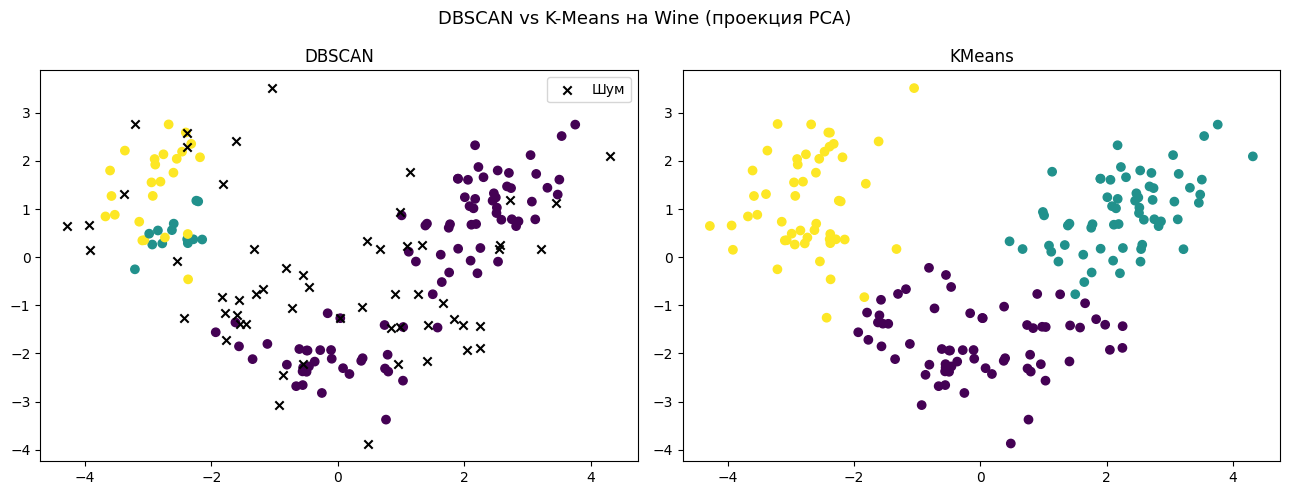

In [97]:
# YOUR CODE HERE
# 1. Обучите KMeans с числом кластеров = числу кластеров DBSCAN
#    (или с n_clusters=3, так как истинных классов 3)
# 2. Вычислите силуэт для K-Means
# 3. Сравните силуэт DBSCAN и K-Means
# 4. Визуализируйте результаты обоих методов в 2D (первые два признака
#    после масштабирования или используйте PCA до 2 компонент)

# Подсказка для PCA:
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_wine_2d = pca.fit_transform(X_wine_scaled)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# DBSCAN
# ваш код

# K-Means
# ваш код
kmeans_wine = KMeans(n_clusters=cn)
kmeans_wine.fit(X_wine_scaled)
labels_km_wine = kmeans_wine.labels_
score_km_wine = silhouette_score(X_wine_scaled, labels_km_wine)

print("Силуэт для kmeans: ", score_km_wine)
print("Силуэт для DBSCAN: ", score_db_wine)

# for i in range(cn):
#     axes[0].scatter()

axes[0].scatter(X_wine_2d[labels_wine != -1, 0], X_wine_2d[labels_wine != -1, 1], c=labels_wine[labels_wine != -1])
axes[0].scatter(X_wine_2d[labels_wine == -1, 0], X_wine_2d[labels_wine == -1, 1], c='black', marker='x', label='Шум')
axes[0].set_title("DBSCAN")
axes[0].legend()

axes[1].scatter(X_wine_2d[:, 0], X_wine_2d[:, 1], c=labels_km_wine)
axes[1].set_title("KMeans")

plt.suptitle("DBSCAN vs K-Means на Wine (проекция PCA)", fontsize=13)
plt.tight_layout()
plt.show()

---
## Шаг 10. Итоговые выводы

Ответьте на следующие вопросы в ячейке ниже (текст Markdown):

**1. Когда DBSCAN выигрывает у K-Means?**

Когда данные линейно неразделимы или как-то вытянуты. KMeans "любит" хорошо сгруппированные в сгустки данные.

**2. Когда K-Means предпочтительнее?**

Когда данные разной плотности и линейно разделимы.

**3. Почему масштабирование обязательно для DBSCAN?**

Так как формула функционала ошибки зависит от расстояния. Из-за этого признаки с большим масштабом будут влиять больше.

**4. Как интерпретировать шумовые точки в датасете Wine?**

Скорее всего это не плохие данные, а реальные аномалии, так как сильно экстремальных значений не было. Поэтому это видимо такие особенные экземпляры.

**5. Можно ли корректно сравнивать силуэт DBSCAN и K-Means напрямую? Почему?**

Нет, так как силуэт "одобряет" плотные, собранные в кучу, похожие на сферу кластеры. Поэтому для DBSCAN'а считать силуэт глупость. DBSCAN может лучше справиться на данных с какой-то необычной формой, линейно неразделимых, отчасти завернутых друг в друга, но силуэт там может быть меньше, чем у KMeans, так как KMeans разделит на плотные облака данных, кластеры будут более кучные и, соответсвтенно, силуэт будет больше.